# Data Quality and Similarity Evalution

This notebook contains the scripts for measuring the Laplacian-based Quality Index (QI) and Similarity Index.

## 0. Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy  as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [3]:
import sys, os, warnings, datetime
warnings.filterwarnings('ignore')

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from lib import transformations, datasets

In [4]:
# Keeping pandas from truncating long strings
pd.set_option('display.max_colwidth',   120)

In [10]:
# Folders constants
data_dir_path = 'data'

dataset_dir_path = f'{data_dir_path}/dataset'
images_dir_path   = f'{data_dir_path}/images/original'

## 1. Dataset

Load the dataframe with data acquired during the collects.

In [11]:
dataset_v0 = pd.read_csv(f'{dataset_dir_path}/suited_dataset.csv')
dataset_v0.shape

(1772, 9)

In [12]:
ds_loader = datasets.Dataset()
images_by_depth = {}

In [13]:
def get_img_file(img_file_name: str):
    
    '''
    Load and transform an image of name [img_file_name] from data folder. 
    '''
    
    if img_file_name in images_by_depth:
        return images_by_depth[img_file_name]
    else: 
        img_file = ds_loader.load_img(
            img_file_name=img_file_name, 
            img_dir=images_dir_path,
            transformations = [
                transformations.NoiseRemovalSetMaxValue(max_value=1950),
                transformations.AdjustScaleWithFixedMaxValue(max_value=1950),
            ]
        )
        images_by_depth[img_file_name] = img_file
        return img_file

## 2. Quality Analysis

In this section, the **QI** index is measured for each image of the suited dataset images.

### 2.1 Measure the Laplacian-based Quality Index (QI)

In [14]:
from skimage.filters import lafarm

vlr_by_img = []
ksize = 3

def measuse_lafarm(row: pd.Series):
    
    img_file_name = row['depth']
    img_file = get_img_file(img_file_name)

    vlr_by_img.append({
        'depth':img_file_name, 
        'qi':np.abs(lafarm(img_file, ksize=ksize)).sum()
    })

dataset_v0.apply(measuse_lafarm, axis=1)
len(vlr_by_img)

1772

In [15]:
ds_qi_by_img_v0 = pd.DataFrame.from_dict(vlr_by_img)
ds_qi_by_img_v0.head()

,depth,qi
0,0200_15565_2025_01_26_09_07_57_912318_DEPTH_320_240_1.png,5943.262695
1,0200_15566_2025_01_26_09_07_58_014755_DEPTH_320_240_1.png,5965.407227
2,0200_15567_2025_01_26_09_07_58_123809_DEPTH_320_240_1.png,5920.653320
3,0200_15569_2025_01_26_09_07_58_344763_DEPTH_320_240_1.png,5831.576172
4,0200_15568_2025_01_26_09_07_58_235040_DEPTH_320_240_1.png,5729.493164


Export the **QI** index to be used in other analysis

In [16]:
import csv

# The keys of the dictionaries become the CSV headers
fieldnames = vlr_by_img[0].keys()

with open(f'output/qi_per_img_{ksize}.csv', 'w', newline='') as csvfile:
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    writer.writeheader()         # Writes the header row
    writer.writerows(vlr_by_img) # Writes all the data rows

### 2.2 Statistical Analysis

In [40]:
farm_A_query = 'farm == "Farm A"'
farm_B_query = 'farm == "Farm B"'

def get_ci(data, conf=0.95):
    '''
    Measure the confidence interval
    '''
    
    if len(data) <= 1: return [np.nan, np.nan]
    ci = stats.t.interval(
        conf, 
        len(data)-1, 
        loc=data.mean(), 
        scale=stats.sem(data)
    )
    
    return f"{ci[0]:.3f} - {ci[1]:.3f}"

In [38]:
dataset_v1 = dataset_v0.merge(ds_qi_by_img_v0, on='depth')
dataset_v1.shape

(1772, 10)

#### General

In [42]:
ds_qi_stats = dataset_v1[['qi']].describe()

ds_qi_stats.loc['cv','qi'] = ds_qi_stats.loc['std','qi'] / ds_qi_stats.loc['mean','qi'] * 100
# ds_qi_stats.loc['ci','qi'] = get_ci(dataset_v1['qi'])

ds_qi_stats

,qi
count,1772.000000
mean,4251.752930
std,1425.475464
min,3034.006348
25%,3299.985474
50%,3410.723755
75%,5858.075562
max,9160.046875
cv,33.526771


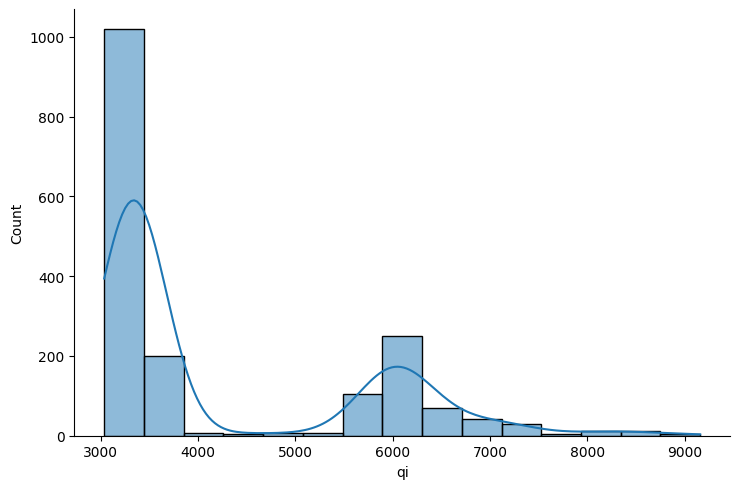

In [43]:
qi_distplot = sns.displot(
    dataset_v1, 
    x="qi",
    aspect=1.5,
    kde=True,
)

#### By Farm

In [44]:
ds_qi_by_farm_stats = dataset_v1.groupby(['farm']).agg({
    'qi':['min', 'mean', 'median', 'max', 'std', 'var', get_ci]
}).reset_index()

ds_qi_by_farm_stats.columns = ['farm', 'min', 'mean', 'median', 'max', 'std', 'var', 'ci']
ds_qi_by_farm_stats['cv'] = ds_qi_by_farm_stats.apply(
    lambda row: row['std'] / row['mean'] * 100, axis=1
)

ds_qi_by_farm_stats.head()

,farm,min,mean,median,max,std,var,ci,cv
0,Farm A,3912.479980,6266.593750,6095.894531,9160.046875,752.718872,566586.500000,6203.777 - 6329.411,12.011611
1,Farm B,3034.006348,3335.315186,3346.054932,3565.091309,104.769348,10976.634766,3329.426 - 3341.205,3.141213


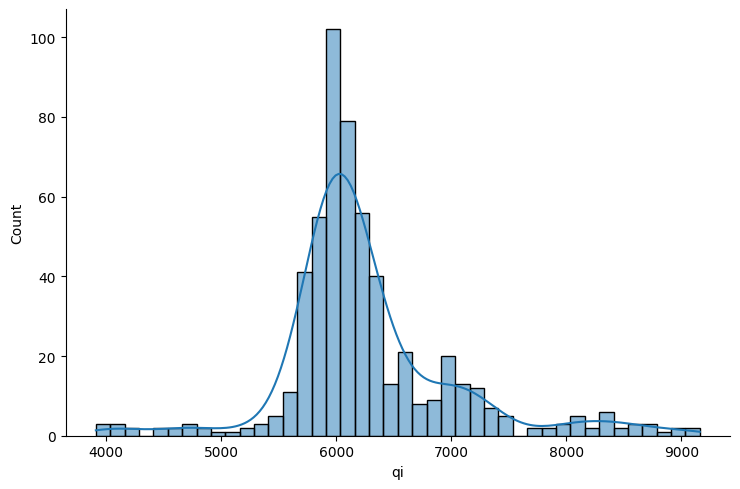

In [45]:
qi_distplot_farmA = sns.displot(
    dataset_v1.query(farm_A_query), 
    x="qi",
    aspect=1.5,
    kde=True,
)

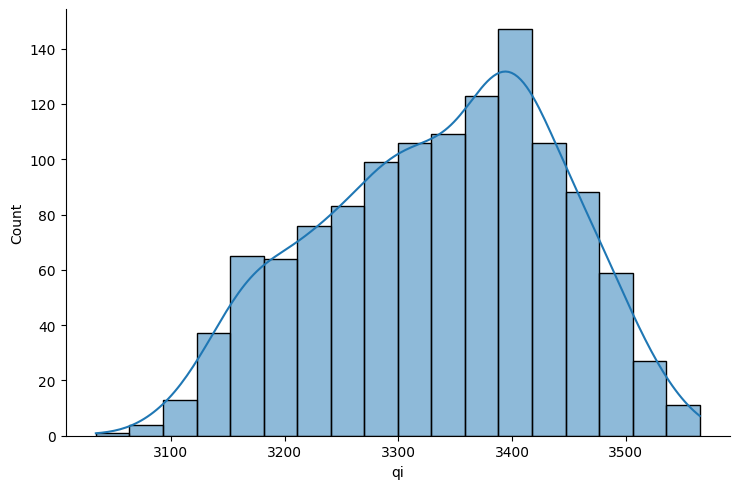

In [46]:
qi_distplot_farmB = sns.displot(
    dataset_v1.query(farm_B_query), 
    x="qi",
    aspect=1.5,
    kde=True,
)

### 2.3 Correlation Analysis - QI x Weight

#### General

In [47]:
correlation_coefficient, p_value = stats.pearsonr(
    dataset_v1['weight'], 
    dataset_v1['qi']
)

print({
    'coeff':correlation_coefficient, 
    'p-value': p_value
})

{'coeff': np.float64(0.14785033012456414), 'p-value': np.float64(4.0062054396455594e-10)}


#### By Farm

In [48]:
corr_dict = {}

# Farm A
correlation_coefficient, p_value = stats.pearsonr(
    dataset_v1.query(farm_A_query)['weight'], 
    dataset_v1.query(farm_A_query)['qi']
)

corr_dict['Farm A'] = {
    'coeff':f'{correlation_coefficient:.8f}',
    'p-value': p_value
}

# Farm B
correlation_coefficient, p_value = stats.pearsonr(
    dataset_v1.query(farm_B_query)['weight'], 
    dataset_v1.query(farm_B_query)['qi']
)
corr_dict['Farm B'] = {
    'coeff':f'{correlation_coefficient:.8f}',
    'p-value': p_value
}

pd.DataFrame.from_dict(corr_dict)

,Farm A,Farm B
coeff,-0.24530958,-0.00083226
p-value,0.0,0.976852


### 2.4 Correlation - QI x Capture Time

#### General

In [49]:
correlation_coefficient, p_value = stats.pearsonr(
    dataset_v1['captured_at_as_min'], 
    dataset_v1['qi']
)
print({
    'coeff':correlation_coefficient, 
    'p-value': p_value
})

{'coeff': np.float64(-0.9276917197360129), 'p-value': np.float64(0.0)}


#### By Farm

In [50]:
corr_dict = {}

# Farm A
correlation_coefficient, p_value = stats.pearsonr(
    dataset_v1.query(farm_A_query)['captured_at_as_min'], 
    dataset_v1.query(farm_A_query)['qi']
)

corr_dict['Farm A'] = {
    'coeff':f'{correlation_coefficient:.8f}',
    'p-value': p_value
}

# Farm B
correlation_coefficient, p_value = stats.pearsonr(
    dataset_v1.query(farm_B_query)['captured_at_as_min'], 
    dataset_v1.query(farm_B_query)['qi']
)
corr_dict['Farm B'] = {
    'coeff':f'{correlation_coefficient:.8f}',
    'p-value': p_value
}

pd.DataFrame.from_dict(corr_dict)

,Farm A,Farm B
coeff,0.41611968,-0.37224716
p-value,0.0,0.0


### 2.5 Intra-animal Variability Index

In [51]:
ds_qi_by_animal_stats = dataset_v1.groupby([
    'farm','animal_id'
]).agg({
    'qi':['min', 'mean', 'median', 'max', 'std', 'var'],
    'captured_at_as_min':['min'],
}).reset_index()

ds_qi_by_animal_stats.columns = [
    'farm', 'animal_id', 'min', 'mean', 'median', 'max', 'std', 'var', 'time'
]
ds_qi_by_animal_stats['cv'] = ds_qi_by_animal_stats.apply(
    lambda row: row['std'] / row['mean'] * 100, axis=1
)

ds_qi_by_animal_stats.head()

,farm,animal_id,min,mean,median,max,std,var,time,cv
0,Farm A,021IK4BJ2GltxzphIRtY,5729.493164,5887.851562,5920.653320,6057.125977,116.588829,13592.968750,547,1.980159
1,Farm A,0H0P02DmDniAyI9krMhA,6111.584961,6218.892578,6195.159180,6342.929688,70.424339,4959.575195,658,1.132426
2,Farm A,0ZwJ8fjJa9TowXrYWhEE,6518.288086,6554.899902,6568.847656,6577.563965,32.004879,1024.321289,668,0.488259
3,Farm A,1blNoXOaGTVs8uJGMp52,5676.834961,5749.948242,5744.840820,5833.276855,66.419373,4411.522949,648,1.155130
4,Farm A,2ttYmLWSz3gTJr7nWhqH,5662.193848,6345.507324,6504.970703,6589.772461,339.899017,115531.335938,645,5.356530


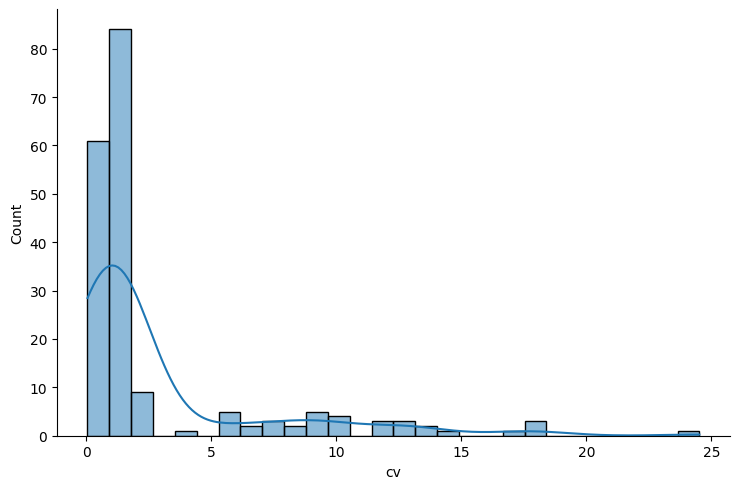

In [52]:
ds_qi_by_animal_distplot = sns.displot(
    ds_qi_by_animal_stats, 
    x="cv",
    aspect=1.5,
    kde=True,
)

#### General

In [54]:
ds_qi_vi_stats = ds_qi_by_animal_stats[['cv']].describe()

ds_qi_vi_stats.loc['vi','cv'] = ds_qi_vi_stats.loc['std','cv'] / ds_qi_vi_stats.loc['mean','cv'] * 100
# ds_qi_vi_stats.loc['ci','cv'] = get_ci(ds_qi_vi_stats['cv'])

ds_qi_vi_stats

,cv
count,190.000000
mean,2.843250
std,4.205674
min,0.043522
25%,0.822661
50%,1.128779
75%,1.566663
max,24.520867
vi,147.917836


In [55]:
correlation_coefficient, p_value = stats.pearsonr(
    ds_qi_by_animal_stats['time'], 
    ds_qi_by_animal_stats['cv']
)
print({
    'coeff':correlation_coefficient, 
    'p-value': p_value
})

{'coeff': np.float64(-0.4155006437386387), 'p-value': np.float64(2.5038884253351157e-09)}


#### By Farm

In [56]:
ds_qi_vi_by_farm_stats = ds_qi_by_animal_stats.groupby('farm').agg({
    'cv':['min', 'mean', 'median', 'max', 'std', 'var', get_ci]
}).reset_index()

ds_qi_vi_by_farm_stats.columns = ['farm', 'min', 'mean', 'median', 'max', 'std', 'var', 'ci']
ds_qi_vi_by_farm_stats['vi'] = ds_qi_vi_by_farm_stats.apply(
    lambda row: row['std'] / row['mean'] * 100, axis=1
)

ds_qi_vi_by_farm_stats.head()

,farm,min,mean,median,max,std,var,ci,vi
0,Farm A,0.378025,4.826902,1.497414,24.520867,5.415513,29.327782,3.699 - 5.955,112.194395
1,Farm B,0.043522,1.019894,1.017637,2.573810,0.407355,0.165938,0.939 - 1.101,39.940892


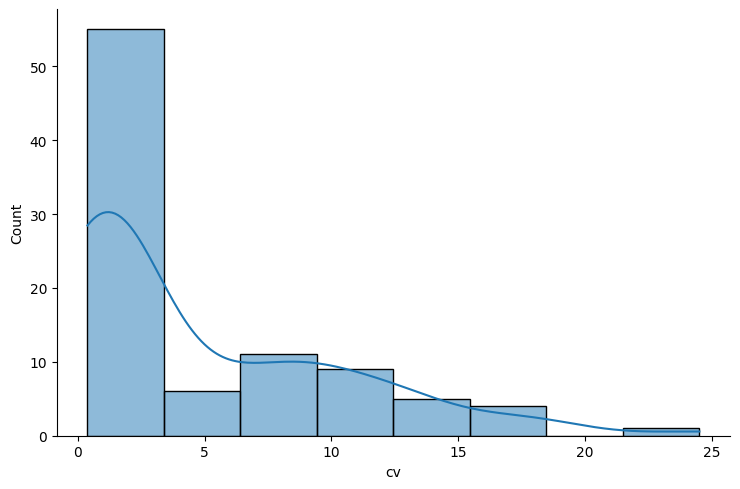

In [57]:
qi_vi_distplot_farmA = sns.displot(
    ds_qi_by_animal_stats.query(farm_A_query), 
    x="cv",
    aspect=1.5,
    kde=True,
)

# qi_vi_distplot_farmA.ax.set_xlim(0, 25)

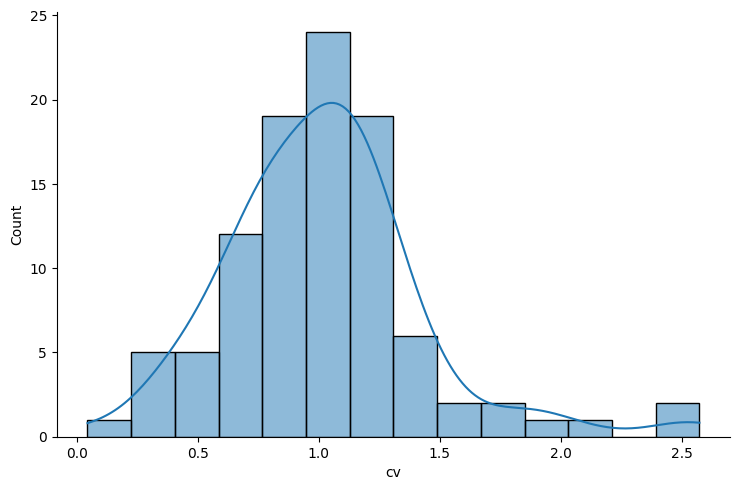

In [58]:
qi_vi_distplot_farmB = sns.displot(
    ds_qi_by_animal_stats.query(farm_B_query), 
    x="cv",
    aspect=1.5,
    kde=True,
)

## 3. Image Similarity Analysis

In this section, the similarity metrics RMSE, SSIM and pHash are measured comparing images in differente scenarios: **overall**, **intra-animal**, **intra-farm** and **inter-farm**.

### Functions

In [59]:
import imagehash

from skimage.metrics import structural_similarity as ssim
from PIL import Image
from scipy.stats import wasserstein_distance

def measure_similarity(img1: np.array, img2: np.array) -> dict:
    '''
    Function that measure the similarity between two images.
    '''
    
    h1 = imagehash.phash(Image.fromarray(img1))
    h2 = imagehash.phash(Image.fromarray(img2))
    
    hist1, _ = np.histogram(img1)
    hist2, _ = np.histogram(img2)
    
    hist1 = hist1.flatten()/hist1.sum()
    hist2 = hist2.flatten()/hist2.sum()
    
    emd = wasserstein_distance(hist2, hist1)
    
    return {
        'ssim':ssim(img2, img1, data_range=1.0),
        'mse':np.mean((img2 - img1) ** 2),
        'rmse':np.mean(np.sqrt((img2 - img1) ** 2)),
        'phash':h2 - h1,
        'emd': emd,
    }

In [60]:
def get_ci(data, conf=0.95):
    '''
    Measure the confidence interval ...
    '''
    
    if len(data) <= 1: return [np.nan, np.nan]
    ci = stats.t.interval(
        conf, 
        len(data)-1, 
        loc=data.mean(), 
        scale=stats.sem(data)
    )
    return (f"{ci[0]:.3f}", f"{ci[1]:.3f}")

def calculate_metrics(data_dict: dict, by_farm_too: bool = True) -> pd.DataFrame:
    '''
    Calculate the similarity metrics agregation ... 
    - data_dict: is a dict in the format:
      {
        'src_type': value,
        'animal_id': value,
        'farm':value,
        'img1_name': value,
        'img2_name': value, 
        'ssim': value, 
        'mse': value,
        'rmse': value, 
        'mpe': value,
        'phash': value,
      }
    '''
    
    ds_dict_v0 = pd.DataFrame.from_dict(data_dict)
    
    # variables
    _cols = ['src_type','ssim_mean','ssim_std','ssim_get_ci','mse_mean','mse_std','mse_get_ci','rmse_mean','rmse_std','rmse_get_ci','phash_mean','phash_std','phash_get_ci','emd_mean','emd_std','emd_get_ci']
    _stats = ['mean','std', get_ci]

    # overall
    ds_stats_v0 = ds_dict_v0.groupby('src_type').agg({
        'ssim':_stats,
        'mse':_stats,
        'rmse':_stats,
        'phash':_stats,
        'emd':_stats,
    }).reset_index()
    
    ds_stats_v0.columns = _cols
    ds_stats_v0['src_type'] = 'overall'

    if not by_farm_too:
        return ds_stats_v0

    # By Farm
    ds_by_farm_stats_v0 = ds_dict_v0.groupby(['farm']).agg({
        'ssim':_stats,
        'mse':_stats,
        'rmse':_stats,
        'phash':_stats,
        'emd':_stats,
    }).reset_index()
    
    ds_by_farm_stats_v0.columns = _cols

    # Final version
    return pd.concat(
        [ds_stats_v0, ds_by_farm_stats_v0], 
        ignore_index=True
    )

### 3.1 Image Similarity Metrics to Whole Data

In this case, the images are compared with other randomly ...

In [66]:
import random

src_overall_dict = []
last_img = None

def overall_sim(row1: pd.Series, row2: pd.Series):
    sim_metrics = measure_similarity(
        img1=get_img_file(row1['depth']), 
        img2=get_img_file(row2['depth'])
    )

    src_overall_dict.append({
        'src_type': 'intra-farm',
        'animal_id':row1['animal_id'],
        'farm': row1['farm'],
        'img1_name': row1['depth'], 
        'img2_name': row2['depth'],
        'ssim':sim_metrics['ssim'],
        'mse':sim_metrics['mse'],
        'rmse':sim_metrics['rmse'],
        'phash':sim_metrics['phash'],
        'emd':sim_metrics['emd'],
    })

animals = list(dataset_v1['animal_id'].unique())
for i in range(0, dataset_v1.shape[0] * 5):
    # Select two unique random values from [animal_set]
    random_values = random.sample(animals, 2)
    
    row1 = dataset_v1.query(f'animal_id == "{random_values[0]}"').sample().iloc[0]
    row2 = dataset_v1.query(f'animal_id == "{random_values[1]}"').sample().iloc[0]
    
    overall_sim(row1=row1, row2=row2)

ds_src_overall_dict_v0 = pd.DataFrame.from_dict(src_overall_dict)
ds_src_overall_dict_v0.head()

,src_type,animal_id,farm,img1_name,img2_name,ssim,mse,rmse,phash,emd
0,intra-farm,3QhziFI8oXXGiVzmqQWR,Farm A,0074_2309_2025_01_25_10_47_52_213976_DEPTH_320_240_1.png,608azf_13561_2025_01_25_17_33_13_396159_DEPTH_320_240_1.png,0.182899,0.045427,0.178414,32,0.042474
1,intra-farm,jk2C4MjFMC0lo4B5Pqra,Farm B,902brf_13693_2025_01_25_17_35_43_103614_DEPTH_320_240_1.png,0127vd_12316_2025_01_25_17_18_35_557354_DEPTH_320_240_1.png,0.626030,0.005232,0.047528,32,0.006333
2,intra-farm,QXbwbDRk5hzMTMmD4wzb,Farm B,014bmf_13342_2025_01_25_17_29_58_442966_DEPTH_320_240_1.png,0606az_7271_2025_01_25_16_53_09_375714_DEPTH_320_240_1.png,0.598442,0.008076,0.055953,32,0.010443
3,intra-farm,VRYlJ6xB3QZ6bRMby3VC,Farm B,0902br_10485_2025_01_25_17_09_15_677917_DEPTH_320_240_1.png,0014vm_6839_2025_01_25_16_51_46_083791_DEPTH_320_240_1.png,0.638661,0.004607,0.041455,0,0.011344
4,intra-farm,IxAJYjvmH7doey9dV7Sy,Farm A,983_943_2025_01_25_10_40_51_063264_DEPTH_320_240_1.png,0047az_8991_2025_01_25_16_59_55_540528_DEPTH_320_240_1.png,0.204505,0.036219,0.156479,0,0.056060


### 3.1 Intra-animal Image Similarity Metrics

Comparison between sequential images of an animal

In [68]:
dataset_v1.columns

Index(['farm', 'animal_id', 'weight', 'woolLevel', 'score',
       'captured_at_as_min', 'depth', 'unexpected_behavior', 'gender', 'qi'],
      dtype='str')

In [70]:
src_intra_animal_dict = []
last_img = None

def intra_animal_sim(row: pd.Series):
    global last_img
    
    img_file_name = row['depth']
    animal_id = row['animal_id']
    img_file = get_img_file(img_file_name)
    
    if last_img is not None and last_img['animal_id'] == animal_id:
        sim_metrics = measure_similarity(
            img1=last_img['data'], 
            img2=img_file
        )

        src_intra_animal_dict.append({
            'src_type': 'intra-animal',
            'animal_id':animal_id,
            'farm': row['farm'],
            'img1_name': last_img['file_name'], 
            'img2_name': img_file_name,
            'ssim':sim_metrics['ssim'],
            'mse':sim_metrics['mse'],
            'rmse':sim_metrics['rmse'],
            'phash':sim_metrics['phash'],
            'emd':sim_metrics['emd'],
        })
    
    last_img = {
        'file_name':img_file_name,
        'data': img_file,
        'animal_id': animal_id
    }

dataset_v1.sort_values(
    by=['animal_id','captured_at_as_min']
).iloc[:,:].apply(intra_animal_sim, axis=1)

ds_src_intra_animal_dict_v0 = pd.DataFrame.from_dict(src_intra_animal_dict)
ds_src_intra_animal_dict_v0.head()

,src_type,animal_id,farm,img1_name,img2_name,ssim,mse,rmse,phash,emd
0,intra-animal,021IK4BJ2GltxzphIRtY,Farm A,0200_15565_2025_01_26_09_07_57_912318_DEPTH_320_240_1.png,0200_15566_2025_01_26_09_07_58_014755_DEPTH_320_240_1.png,0.370244,0.010805,0.070396,0,0.001982
1,intra-animal,021IK4BJ2GltxzphIRtY,Farm A,0200_15566_2025_01_26_09_07_58_014755_DEPTH_320_240_1.png,0200_15567_2025_01_26_09_07_58_123809_DEPTH_320_240_1.png,0.370930,0.010254,0.068875,0,0.003242
2,intra-animal,021IK4BJ2GltxzphIRtY,Farm A,0200_15567_2025_01_26_09_07_58_123809_DEPTH_320_240_1.png,0200_15569_2025_01_26_09_07_58_344763_DEPTH_320_240_1.png,0.359308,0.012000,0.076217,0,0.008906
3,intra-animal,021IK4BJ2GltxzphIRtY,Farm A,0200_15569_2025_01_26_09_07_58_344763_DEPTH_320_240_1.png,0200_15568_2025_01_26_09_07_58_235040_DEPTH_320_240_1.png,0.389101,0.011280,0.071721,0,0.006393
4,intra-animal,021IK4BJ2GltxzphIRtY,Farm A,0200_15568_2025_01_26_09_07_58_235040_DEPTH_320_240_1.png,0200_15570_2025_01_26_09_07_58_448220_DEPTH_320_240_1.png,0.347737,0.013666,0.080497,0,0.007734


### 3.2 Intra-farm Image Similarity Metrics

In this case, the images are compared with images of the same farm but from different animal

In [71]:
import random

src_intra_farm_dict = []
last_img = None

def intra_farm_sim(row1: pd.Series, row2: pd.Series):
    sim_metrics = measure_similarity(
        img1=get_img_file(row1['depth']), 
        img2=get_img_file(row2['depth'])
    )

    src_intra_farm_dict.append({
        'src_type': 'intra-farm',
        'animal_id':row1['animal_id'],
        'farm': row1['farm'],
        'img1_name': row1['depth'], 
        'img2_name': row2['depth'],
        'ssim':sim_metrics['ssim'],
        'mse':sim_metrics['mse'],
        'rmse':sim_metrics['rmse'],
        'phash':sim_metrics['phash'],
        'emd':sim_metrics['emd'],
    })

# Farm A
ds_farm_A = dataset_v1.query(farm_A_query).iloc[:,:]

animals = list(ds_farm_A['animal_id'].unique())
for i in range(0, ds_farm_A.shape[0] * 5):
    # Select two unique random values from [animal_set]
    random_values = random.sample(animals, 2)
    
    row1 = ds_farm_A.query(f'animal_id == "{random_values[0]}"').sample().iloc[0]
    row2 = ds_farm_A.query(f'animal_id == "{random_values[1]}"').sample().iloc[0]
    
    intra_farm_sim(row1=row1, row2=row2)

# Farm B
ds_farm_B = dataset_v1.query(farm_B_query).iloc[:,:]

animals = list(ds_farm_B['animal_id'].unique())
for i in range(0, ds_farm_B.shape[0] * 5):
    # Select two unique random values from [animal_set]
    random_values = random.sample(animals, 2)
    
    row1 = ds_farm_B.query(f'animal_id == "{random_values[0]}"').sample().iloc[0]
    row2 = ds_farm_B.query(f'animal_id == "{random_values[1]}"').sample().iloc[0]
    
    intra_farm_sim(row1=row1, row2=row2)

ds_src_intra_farm_dict_v0 = pd.DataFrame.from_dict(src_intra_farm_dict)
ds_src_intra_farm_dict_v0.head()

,src_type,animal_id,farm,img1_name,img2_name,ssim,mse,rmse,phash,emd
0,intra-farm,zbbrTxhhcZBu0NL7dnuZ,Farm A,59_3769_2025_01_25_10_59_17_013332_DEPTH_320_240_1.png,0050_16782_2025_01_26_09_14_00_496788_DEPTH_320_240_1.png,0.299178,0.032656,0.151640,0,0.021409
1,intra-farm,K9QKYRo1klTQfDuj58rZ,Farm A,997_5322_2025_01_25_11_08_46_029817_DEPTH_320_240_1.png,0126_1266_2025_01_25_10_42_32_489766_DEPTH_320_240_1.png,0.268701,0.035526,0.156734,32,0.023005
2,intra-farm,gOknL17oYR2BnAKt2pPB,Farm A,978_3075_2025_01_25_10_51_52_919237_DEPTH_320_240_1.png,986_3611_2025_01_25_10_58_10_360289_DEPTH_320_240_1.png,0.332444,0.015376,0.092080,0,0.021135
3,intra-farm,021IK4BJ2GltxzphIRtY,Farm A,0200_15565_2025_01_26_09_07_57_912318_DEPTH_320_240_1.png,0458_3947_2025_01_25_11_00_23_272242_DEPTH_320_240_1.png,0.225120,0.031273,0.144001,0,0.020156
4,intra-farm,3QhziFI8oXXGiVzmqQWR,Farm A,0074_2309_2025_01_25_10_47_52_213976_DEPTH_320_240_1.png,903_16562_2025_01_26_09_12_49_569119_DEPTH_320_240_1.png,0.232995,0.027706,0.127460,0,0.021164


### 3.3 Inter-farm Image Similarity Metrics

In this case, the images are compared with images of other farm animal

In [72]:
import random

src_between_farm_dict = []
last_img = None

def between_farm_sim(row1: pd.Series, row2: pd.Series):
    sim_metrics = measure_similarity(
        img1=get_img_file(row1['depth']), 
        img2=get_img_file(row2['depth'])
    )

    src_between_farm_dict.append({
        'src_type': 'inter-farm',
        'animal_id':row1['animal_id'],
        'farm': row1['farm'],
        'img1_name': row1['depth'], 
        'img2_name': row2['depth'],
        'ssim':sim_metrics['ssim'],
        'mse':sim_metrics['mse'],
        'rmse':sim_metrics['rmse'],
        'phash':sim_metrics['phash'],
        'emd':sim_metrics['emd'],
    })

# Farm A
ds_farm_A = dataset_v1.query(farm_A_query).iloc[:,:]
farm_A_animals = list(ds_farm_A['animal_id'].unique())

# Farm B
ds_farm_B = dataset_v1.query(farm_B_query).iloc[:,:]
farm_B_animals = list(ds_farm_B['animal_id'].unique())

for i in range(0, dataset_v1.shape[0] * 5):
    # Select two unique random values from [animal_set]
    farm_A_id = random.sample(farm_A_animals, 1)
    farm_B_id = random.sample(farm_B_animals, 1)
    
    row1 = ds_farm_A.query(f'animal_id == "{farm_A_id[0]}"').sample().iloc[0]
    row2 = ds_farm_B.query(f'animal_id == "{farm_B_id[0]}"').sample().iloc[0]
    
    between_farm_sim(row1=row1, row2=row2)

ds_src_between_farm_dict_v0 = pd.DataFrame.from_dict(src_between_farm_dict)
ds_src_between_farm_dict_v0.head()

,src_type,animal_id,farm,img1_name,img2_name,ssim,mse,rmse,phash,emd
0,inter-farm,IxAJYjvmH7doey9dV7Sy,Farm A,983_943_2025_01_25_10_40_51_063264_DEPTH_320_240_1.png,0005az_10828_2025_01_25_17_11_07_827619_DEPTH_320_240_1.png,0.220165,0.038891,0.164849,0,0.060128
1,inter-farm,4VVduhuUTmpx3gEC5Rir,Farm A,0013_15623_2025_01_26_09_08_27_407146_DEPTH_320_240_1.png,0060az_10082_2025_01_25_17_05_39_287216_DEPTH_320_240_1.png,0.317000,0.031189,0.144418,0,0.039094
2,inter-farm,ThIUfsQhpcxZBUn5tiGy,Farm A,0468_763_2025_01_25_10_39_51_320403_DEPTH_320_240_1.png,0067vd_6564_2025_01_25_16_49_41_774022_DEPTH_320_240_1.png,0.249810,0.037220,0.165048,0,0.047622
3,inter-farm,NOs7Rn6OQxLaeFKDU8n9,Farm A,973_4824_2025_01_25_11_06_44_530131_DEPTH_320_240_1.png,608azf_13566_2025_01_25_17_33_13_940828_DEPTH_320_240_1.png,0.250799,0.075719,0.216750,32,0.077865
4,inter-farm,c1MczikEl7cJRzBwSyFL,Farm A,984_5927_2025_01_25_11_13_27_623003_DEPTH_320_240_1.png,0084az_10768_2025_01_25_17_10_51_972512_DEPTH_320_240_1.png,0.175778,0.044664,0.170644,0,0.057510


### 3.4 Image Similarity Analysis

#### Statistical Analysis

In [73]:
ds_src_overall_agg_v0 = calculate_metrics(data_dict=src_overall_dict, by_farm_too=False)
ds_src_overall_agg_v0.head()

,src_type,ssim_mean,ssim_std,ssim_get_ci,mse_mean,mse_std,mse_get_ci,rmse_mean,rmse_std,rmse_get_ci,phash_mean,phash_std,phash_get_ci,emd_mean,emd_std,emd_get_ci
0,overall,0.363968,0.168716,"(0.360, 0.367)",0.029472,0.019488,"(0.029, 0.030)",0.126243,0.05625,"(0.125, 0.127)",11.969752,15.524331,"(11.646, 12.293)",0.034658,0.023417,"(0.034, 0.035)"


In [74]:
# agregate the similarity metrics overall and by farm
ds_src_intra_animal_agg_v0 = calculate_metrics(data_dict=src_intra_animal_dict)
ds_src_intra_animal_agg_v0.head()

,src_type,ssim_mean,ssim_std,ssim_get_ci,mse_mean,mse_std,mse_get_ci,rmse_mean,rmse_std,rmse_get_ci,phash_mean,phash_std,phash_get_ci,emd_mean,emd_std,emd_get_ci
0,overall,0.565092,0.127201,"(0.559, 0.571)",0.006959,0.003832,"(0.007, 0.007)",0.052887,0.016268,"(0.052, 0.054)",11.969027,15.788199,"(11.190, 12.748)",0.006997,0.004333,"(0.007, 0.007)"
1,Farm A,0.373277,0.041759,"(0.369, 0.377)",0.011782,0.002711,"(0.012, 0.012)",0.074824,0.009547,"(0.074, 0.076)",3.632829,9.959831,"(2.723, 4.542)",0.008591,0.005369,"(0.008, 0.009)"
2,Farm B,0.644457,0.024873,"(0.643, 0.646)",0.004963,0.002028,"(0.005, 0.005)",0.043810,0.007407,"(0.043, 0.044)",15.418231,16.456542,"(14.453, 16.383)",0.006338,0.003627,"(0.006, 0.007)"


In [75]:
ds_src_intra_farm_agg_v0 = calculate_metrics(data_dict=src_intra_farm_dict)
ds_src_intra_farm_agg_v0.head()

,src_type,ssim_mean,ssim_std,ssim_get_ci,mse_mean,mse_std,mse_get_ci,rmse_mean,rmse_std,rmse_get_ci,phash_mean,phash_std,phash_get_ci,emd_mean,emd_std,emd_get_ci
0,overall,0.535680,0.154388,"(0.532, 0.539)",0.010877,0.008685,"(0.011, 0.011)",0.067583,0.032951,"(0.067, 0.068)",13.199323,15.942158,"(12.867, 13.531)",0.010789,0.006413,"(0.011, 0.011)"
1,Farm A,0.312459,0.049545,"(0.311, 0.314)",0.021536,0.008301,"(0.021, 0.022)",0.110242,0.027116,"(0.109, 0.111)",7.305415,13.385951,"(6.807, 7.804)",0.016585,0.007116,"(0.016, 0.017)"
2,Farm B,0.637210,0.024192,"(0.637, 0.638)",0.006029,0.001798,"(0.006, 0.006)",0.048180,0.006400,"(0.048, 0.048)",15.880131,16.287895,"(15.471, 16.289)",0.008153,0.003820,"(0.008, 0.008)"


In [76]:
ds_src_between_farm_agg_v0 = calculate_metrics(data_dict=src_between_farm_dict, by_farm_too=False)
ds_src_between_farm_agg_v0.head()

,src_type,ssim_mean,ssim_std,ssim_get_ci,mse_mean,mse_std,mse_get_ci,rmse_mean,rmse_std,rmse_get_ci,phash_mean,phash_std,phash_get_ci,emd_mean,emd_std,emd_get_ci
0,overall,0.245156,0.030452,"(0.245, 0.246)",0.045283,0.012417,"(0.045, 0.046)",0.174057,0.018958,"(0.174, 0.174)",11.906659,15.440208,"(11.585, 12.228)",0.056445,0.007677,"(0.056, 0.057)"


In [77]:
pd.concat([
    ds_src_overall_agg_v0,
    ds_src_intra_animal_agg_v0,
    ds_src_intra_farm_agg_v0,
    ds_src_between_farm_agg_v0,    
])

,src_type,ssim_mean,ssim_std,ssim_get_ci,mse_mean,mse_std,mse_get_ci,rmse_mean,rmse_std,rmse_get_ci,phash_mean,phash_std,phash_get_ci,emd_mean,emd_std,emd_get_ci
0,overall,0.363968,0.168716,"(0.360, 0.367)",0.029472,0.019488,"(0.029, 0.030)",0.126243,0.056250,"(0.125, 0.127)",11.969752,15.524331,"(11.646, 12.293)",0.034658,0.023417,"(0.034, 0.035)"
0,overall,0.565092,0.127201,"(0.559, 0.571)",0.006959,0.003832,"(0.007, 0.007)",0.052887,0.016268,"(0.052, 0.054)",11.969027,15.788199,"(11.190, 12.748)",0.006997,0.004333,"(0.007, 0.007)"
1,Farm A,0.373277,0.041759,"(0.369, 0.377)",0.011782,0.002711,"(0.012, 0.012)",0.074824,0.009547,"(0.074, 0.076)",3.632829,9.959831,"(2.723, 4.542)",0.008591,0.005369,"(0.008, 0.009)"
2,Farm B,0.644457,0.024873,"(0.643, 0.646)",0.004963,0.002028,"(0.005, 0.005)",0.043810,0.007407,"(0.043, 0.044)",15.418231,16.456542,"(14.453, 16.383)",0.006338,0.003627,"(0.006, 0.007)"
0,overall,0.535680,0.154388,"(0.532, 0.539)",0.010877,0.008685,"(0.011, 0.011)",0.067583,0.032951,"(0.067, 0.068)",13.199323,15.942158,"(12.867, 13.531)",0.010789,0.006413,"(0.011, 0.011)"
1,Farm A,0.312459,0.049545,"(0.311, 0.314)",0.021536,0.008301,"(0.021, 0.022)",0.110242,0.027116,"(0.109, 0.111)",7.305415,13.385951,"(6.807, 7.804)",0.016585,0.007116,"(0.016, 0.017)"
2,Farm B,0.637210,0.024192,"(0.637, 0.638)",0.006029,0.001798,"(0.006, 0.006)",0.048180,0.006400,"(0.048, 0.048)",15.880131,16.287895,"(15.471, 16.289)",0.008153,0.003820,"(0.008, 0.008)"
0,overall,0.245156,0.030452,"(0.245, 0.246)",0.045283,0.012417,"(0.045, 0.046)",0.174057,0.018958,"(0.174, 0.174)",11.906659,15.440208,"(11.585, 12.228)",0.056445,0.007677,"(0.056, 0.057)"


### 3.5 Qualitative Analysis

In [78]:
import matplotlib as mpl

mpl.rc('xtick', labelsize=12) 
mpl.rc('ytick', labelsize=12) 

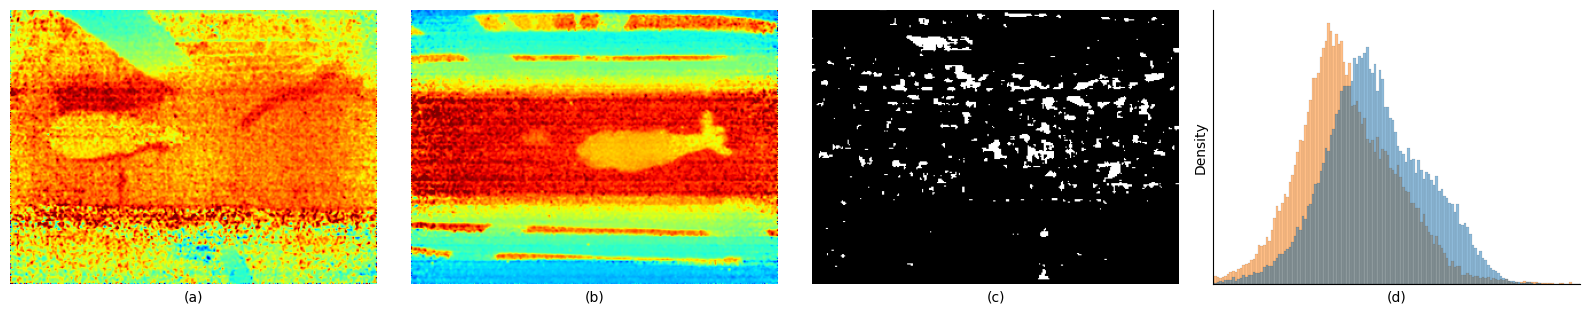

In [80]:
img1 = images_by_depth['985_819_2025_01_25_10_40_13_798216_DEPTH_320_240_1.png']
img2 = images_by_depth['0131az_12243_2025_01_25_17_18_14_262463_DEPTH_320_240_1.png']

from skimage.metrics import structural_similarity as ssim
_, mask = ssim(img1, img2, full=True, data_range=1)

mask = mask > 0.6

# Perform the 2D Fast Fourier Transform (FFT)
f_transform1 = np.fft.fft2(img1)
f_transform2 = np.fft.fft2(img2)

arr1 = np.log(np.abs(f_transform1.flatten()))
arr2 = np.log(np.abs(f_transform2.flatten()))

hist_df = pd.DataFrame({
    'value': np.concatenate([arr1, arr2]), 
    'img': ['img1']*len(arr1) + ['img2']*len(arr2)
})

# Visualization
_cmap = 'jet'

fig, ax = plt.subplots(1, 4, figsize=(16, 12))

ax[0].imshow(img1, cmap=_cmap); 
ax[0].set_xlabel('(a)')

ax[1].imshow(img2, cmap=_cmap); 
ax[1].set_xlabel('(b)')

ax[2].imshow(mask, cmap='grey'); 
ax[2].set_xlabel('(c)')

sns.histplot(hist_df, x='value', hue='img', stat="density", ax=ax[3], legend=True);
sns.despine()

ax[3].set_box_aspect(0.75)
ax[3].set_xlabel('(d)')
ax[3].set_xlim(-1, 6)
ax[3].get_legend().remove()
ax[3].set_xticks([])
ax[3].set_yticks([])

for x in ax[:3]:
    x.set_xticks([])
    x.set_yticks([])
    for spine in x.spines.values():
        spine.set_visible(False)

plt.tight_layout()
plt.savefig("output/fig_07b_ssim_x_pHash_samples.png", dpi=300, bbox_inches="tight")

plt.show()